In [ ]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
sim = AerSimulator(method='statevector')

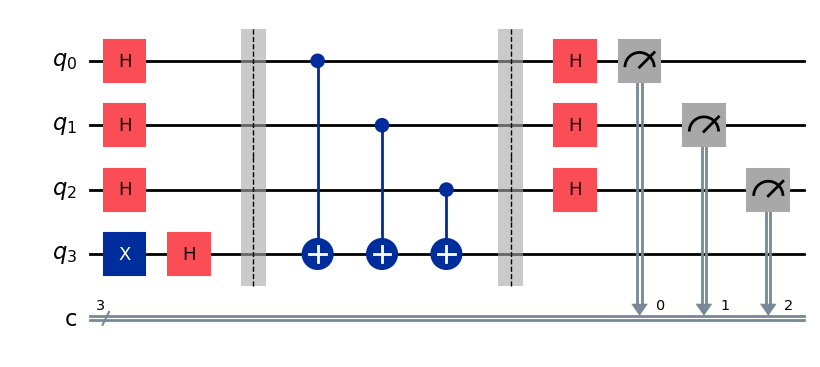

In [ ]:
n=int(input("Enter number of qubits:" ))
oracle_type = input("Choose oracle (constant/balanced): ").lower()
# create a circuit
circuit=QuantumCircuit(n+1,n)

# apply x gate on the last qubit
circuit.x(n)

# apply Hadamard on all qubits
circuit.h(range(n+1))

circuit.barrier()

# create Oracle Uf
if oracle_type == "constant":
    # Example: f(x)=0 (do nothing)
    pass

elif oracle_type == "balanced":
    # Example balanced oracle
    for i in range(n):
        circuit.cx(i, n)

else:
    print("Invalid oracle type")
    exit()


circuit.barrier()


circuit.h(range(n))

circuit.measure(range(n),range(n))

circuit.draw('mpl',filename='dj_circuit.png')

In [ ]:
result = sim.run(transpile(circuit, sim), shots=1024).result()
counts = result.get_counts()
print("Measurement results:", counts)

Measurement results: {'111': 1024}


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


In [ ]:
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Load IBM account
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Select least busy real device
backend = service.least_busy(
    simulator=False,
    operational=True
)

print("Running on:", backend.name)

# Transpile circuit for target backend
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuit = pm.run(circuit)

# Create sampler
sampler = SamplerV2(mode=backend)

# Run job
job = sampler.run([isa_circuit], shots=1024)

print("Job ID:", job.job_id())

result = job.result()

# Extract counts
counts = result[0].data.c.get_counts()

print("Measurement results:")
print(counts)


qiskit_runtime_service.__init__:WARNING:2026-06-23 12:36:17,323: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-23 12:36:17,670: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-23 12:36:19,848: Using instance: open-instance, plan: open


Running on: ibm_fez
Job ID: d8tbc34bp3hs73849rqg
Measurement results:
{'111': 960, '011': 23, '101': 18, '001': 5, '110': 15, '000': 2, '010': 1}


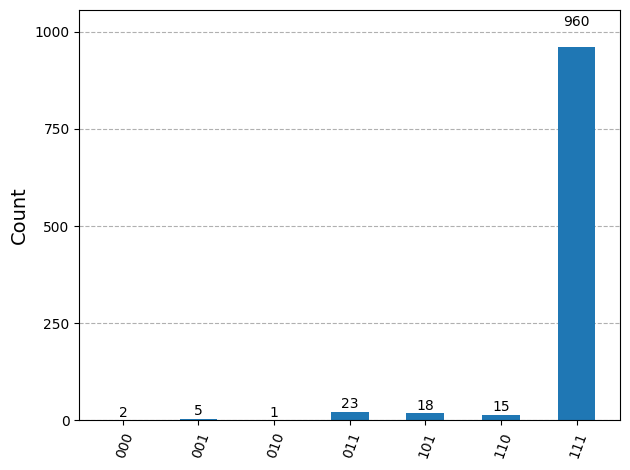

In [ ]:
plot_histogram(counts)